# Modèle Spécialisé - Prédiction de Genre

Ce notebook implémente un modèle de deep learning spécialisé dans la classification du genre à partir de photos de visages.

**Architecture:** Transfer Learning avec EfficientNetB0
**Tâche:** Classification binaire
**Dataset:** UTKFace (23,708 images)

**Classes:**

- 0: Male (Homme)
- 1: Female (Femme)


## 1. Configuration et Imports


In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titlesize": 14})

TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Constantes et Hyperparamètres


In [2]:
# Chemins
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data" / "UTKFace"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Classes de genre
GENDER_MAP = {0: "Male", 1: "Female"}
NUM_CLASSES = 2
CLASS_NAMES = list(GENDER_MAP.values())

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 12
FINETUNE_EPOCHS = 30
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

print(f"Configuration:")
print(f"  - Classes: {CLASS_NAMES}")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")

Configuration:
  - Classes: ['Male', 'Female']
  - Image size: 128x128
  - Batch size: 32


## 3. Chargement des Données


In [3]:
def parse_utkface_filename(filepath: Path) -> dict | None:
    """Parse les métadonnées depuis le nom de fichier UTKFace."""
    try:
        name = filepath.name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 2:
            return None

        gender = int(parts[1]) if parts[1].isdigit() else -1

        # Filtrer les genres invalides (garder uniquement 0 et 1)
        if gender not in [0, 1]:
            return None

        return {
            "filepath": str(filepath),
            "gender": gender,
            "gender_name": GENDER_MAP.get(gender, "Unknown"),
        }
    except Exception:
        return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing des fichiers"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")

Images trouvées: 23708


Parsing des fichiers: 100%|██████████| 23708/23708 [00:00<00:00, 1495789.03it/s]


Images valides: 23708


Distribution des genres:
gender_name
Male      12391
Female    11317
Name: count, dtype: int64


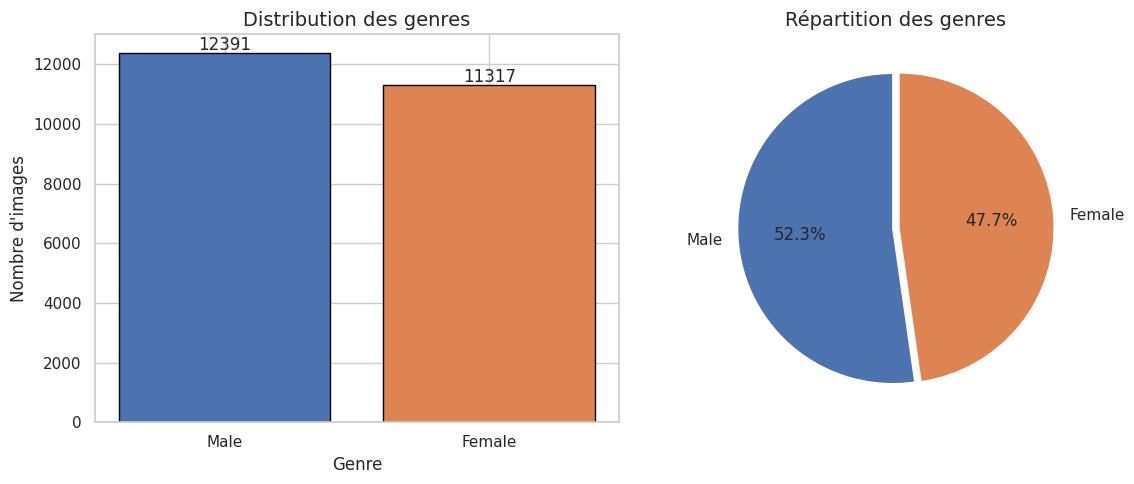


Ratio hommes/femmes: 1.09


In [4]:
# Distribution des classes
print("Distribution des genres:")
class_counts = df["gender_name"].value_counts()
print(class_counts)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ["#4C72B0", "#DD8452"]
class_counts_sorted = df["gender"].value_counts().sort_index()
axes[0].bar(
    [GENDER_MAP[i] for i in class_counts_sorted.index],
    class_counts_sorted.values,
    color=colors,
    edgecolor="black",
)
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des genres")
for i, v in enumerate(class_counts_sorted.values):
    axes[0].text(i, v + 100, str(v), ha="center", fontsize=12)

# Pie chart
axes[1].pie(
    class_counts_sorted.values,
    labels=[GENDER_MAP[i] for i in class_counts_sorted.index],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=(0.02, 0.02),
)
axes[1].set_title("Répartition des genres")

plt.tight_layout()
plt.show()

# Ratio
ratio = class_counts.max() / class_counts.min()
print(f"\nRatio hommes/femmes: {ratio:.2f}")

## 4. Split Train/Validation/Test (Stratifié)


In [5]:
# Split stratifié
X = df["filepath"].values
y = df["gender"].values

# Premier split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

# Deuxième split: train vs val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED,
)

print(f"Split des données:")
print(f"  - Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Vérifier la stratification
print(f"\nDistribution dans le train set:")
for g in [0, 1]:
    count = (y_train == g).sum()
    print(f"  - {GENDER_MAP[g]}: {count} ({count/len(y_train)*100:.1f}%)")

Split des données:
  - Train: 18966 (80.0%)
  - Validation: 2371 (10.0%)
  - Test: 2371 (10.0%)

Distribution dans le train set:
  - Male: 9913 (52.3%)
  - Female: 9053 (47.7%)


## 5. Calcul des Poids de Classes


In [6]:
# Poids de classes pour équilibrer
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print("Poids des classes:")
for cls, weight in class_weights.items():
    print(f"  - {GENDER_MAP[cls]}: {weight:.3f}")

Poids des classes:
  - Male: 0.957
  - Female: 1.047


## 7. Pipeline de Données avec Data Augmentation


In [7]:
# Data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),  # ±8% (moins que pour l'âge/ethnicité)
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)


def load_and_preprocess(filepath, label):
    """Charge et prétraite une image (sans normalisation pour permettre l'augmentation)."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def create_dataset(filepaths, labels, batch_size, shuffle=True, augment=False):
    """Crée un tf.data.Dataset."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Créer les datasets
train_ds = create_dataset(X_train, y_train, BATCH_SIZE, shuffle=True, augment=True)
val_ds = create_dataset(X_val, y_val, BATCH_SIZE, shuffle=False, augment=False)
test_ds = create_dataset(X_test, y_test, BATCH_SIZE, shuffle=False, augment=False)

print("Datasets créés avec succès!")

I0000 00:00:1768736733.030906   38776 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1908 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Datasets créés avec succès!


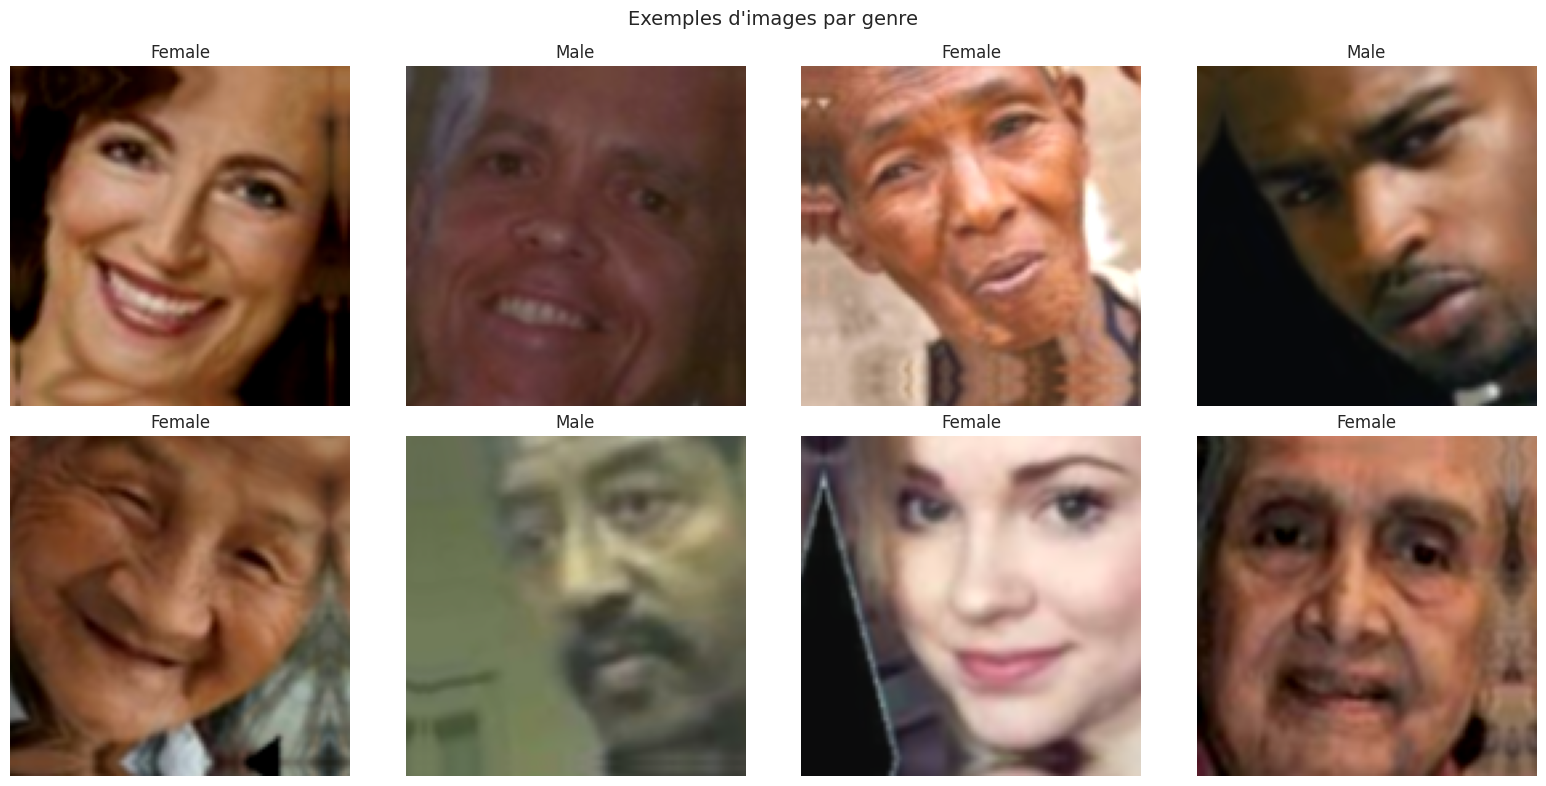

In [8]:
# Visualiser quelques exemples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            # Images sont en [0, 255], normaliser pour affichage
            img = images[i].numpy() / 255.0
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.set_title(f"{GENDER_MAP[labels[i].numpy()]}", fontsize=12)
            ax.axis("off")

plt.suptitle("Exemples d'images par genre", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Construction du Modèle


In [9]:
def build_gender_model(img_size: int, trainable_backbone: bool = False) -> Model:
    """Construit le modèle de classification de genre avec EfficientNetB0."""

    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # Backbone EfficientNetB0
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # Double pooling (GAP + GMP) pour capturer plus d'informations
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head de classification binaire
    x = layers.Dense(128, activation="relu", name="dense_1")(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x)

    x = layers.Dense(32, activation="relu", name="dense_2")(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)

    # Output binaire (sigmoid)
    outputs = layers.Dense(1, activation="sigmoid", name="gender_output")(x)

    model = Model(inputs, outputs, name="GenderModel_EfficientNetB0")
    return model, backbone


# Construire le modèlemodel.summary()
model, backbone = build_gender_model(IMG_SIZE, trainable_backbone=False)

## 9. Phase 1: Warmup (Backbone Gelé)


In [10]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR, decay_steps=total_warmup_steps, alpha=0.1
)

model.compile(
    optimizer=Adam(learning_rate=warmup_lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "gender_warmup_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    # Note: Pas de ReduceLROnPlateau car CosineDecay gère déjà la décroissance du LR
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")
print(
    f"Paramètres entraînables: {sum([tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]):,}"
)

Phase 1: Warmup (12 epochs, backbone gelé)
Paramètres entraînables: 332,289


In [11]:
# Entraînement Phase 1
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/12


2026-01-18 12:45:47.977184: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:45:48.062011: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:45:48.147849: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:45:48.553791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:45:48.643838: E external/local_xla/xla/stream_

589/593 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7462 - auc: 0.8212 - loss: 0.5387

2026-01-18 12:46:07.570225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:07.655147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:08.039553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:08.129342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:08.558054: E external/local_xla/xla/stream_

593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7464 - auc: 0.8214 - loss: 0.5383

2026-01-18 12:46:21.115282: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:21.200251: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:21.285359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:21.370607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:46:21.455596: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.82412, saving model to /home/optimalako/Projet/SAE/artifacts/gender_warmup_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_warmup_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 49s 54ms/step - accuracy: 0.7759 - auc: 0.8575 - loss: 0.4764 - val_accuracy: 0.8241 - val_auc: 0.9174 - val_loss: 0.3725
Epoch 2/12
589/593 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8014 - auc: 0.8858 - loss: 0.4256
Epoch 2: val_accuracy improved from 0.82412 to 0.83045, saving model to /home/optimalako/Projet/SAE/artifacts/gender_warmup_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_warmup_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8025 - auc: 0.8888 - loss: 0.4196 - val_accuracy: 0.8305 - val_auc: 0.9220 - val_loss: 0.3741
Epoch 3/12
592/593 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8044 - auc: 0.8899 - loss: 0.4188
Epoch 3: val_accuracy improved f

## 10. Phase 2: Fine-tuning


In [12]:
# Dégeler les dernières couches du backbone
backbone.trainable = True

freeze_until = len(backbone.layers) - 40  # Un peu moins que pour les autres modèles
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (30 epochs)
Couches dégelées: 40/238
Paramètres entraînables: 2,382,993


In [13]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR, decay_steps=total_finetune_steps, alpha=0.01
)

model.compile(
    optimizer=Adam(learning_rate=finetune_lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "gender_model_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
    # Note: Pas de ReduceLROnPlateau car CosineDecay gère déjà la décroissance du LR
]

In [14]:
# Entraînement Phase 2
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/30
590/593 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7338 - auc: 0.8082 - loss: 0.5564

2026-01-18 12:48:49.951355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:48:50.038910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


593/593 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7339 - auc: 0.8084 - loss: 0.5561
Epoch 1: val_accuracy improved from None to 0.82244, saving model to /home/optimalako/Projet/SAE/artifacts/gender_model_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_model_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.7589 - auc: 0.8359 - loss: 0.5133 - val_accuracy: 0.8224 - val_auc: 0.9025 - val_loss: 0.3955
Epoch 2/30
591/593 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7870 - auc: 0.8692 - loss: 0.4560
Epoch 2: val_accuracy improved from 0.82244 to 0.83762, saving model to /home/optimalako/Projet/SAE/artifacts/gender_model_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_model_best.keras
593/593 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.7916 - auc: 0.8758 - loss: 0.4445 - val_accuracy: 0.8376 - val_auc: 0.9195 - val_loss: 0.3614
Epoch 3/30
591/593 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/

## 11. Visualisation de l'Entraînement


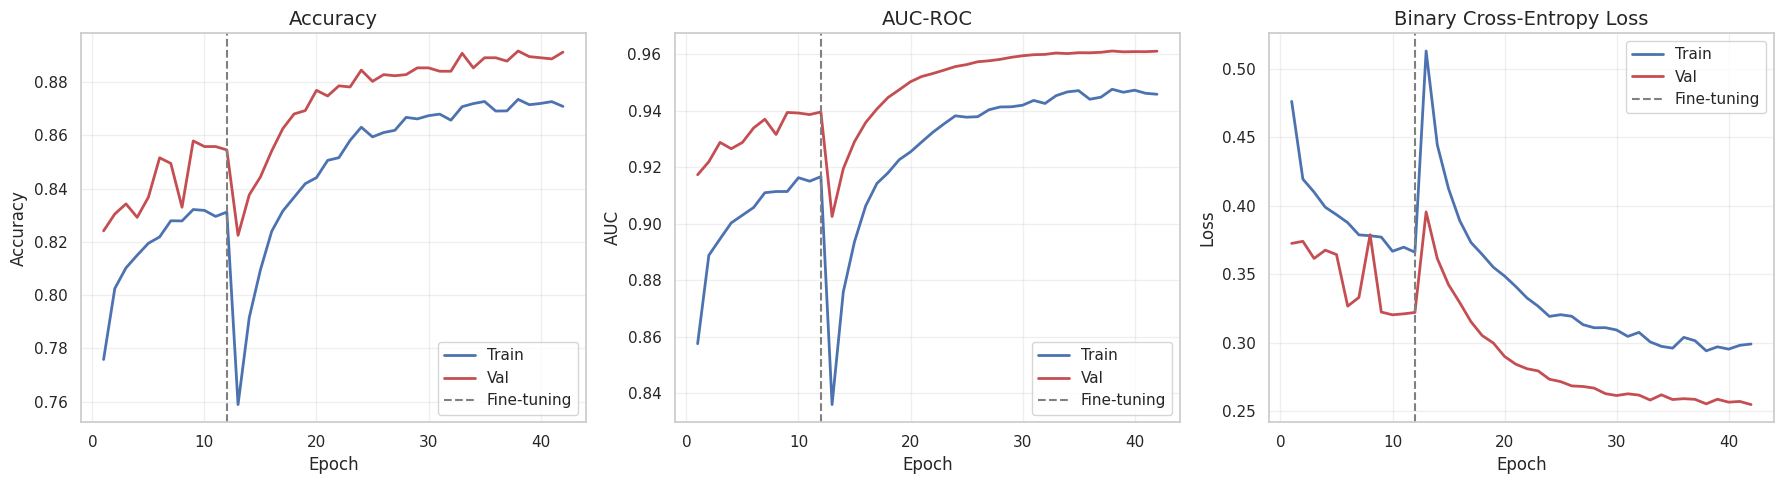


Meilleure Val Accuracy: 0.8916 (epoch 38)
Meilleur Val AUC: 0.9612


In [15]:
def plot_training_history(warmup_hist, finetune_hist):
    """Visualise l'historique d'entraînement."""
    combined_acc = warmup_hist.history["accuracy"] + finetune_hist.history["accuracy"]
    combined_val_acc = (
        warmup_hist.history["val_accuracy"] + finetune_hist.history["val_accuracy"]
    )
    combined_auc = warmup_hist.history["auc"] + finetune_hist.history["auc"]
    combined_val_auc = warmup_hist.history["val_auc"] + finetune_hist.history["val_auc"]
    combined_loss = warmup_hist.history["loss"] + finetune_hist.history["loss"]
    combined_val_loss = (
        warmup_hist.history["val_loss"] + finetune_hist.history["val_loss"]
    )

    epochs = range(1, len(combined_acc) + 1)
    warmup_end = len(warmup_hist.history["accuracy"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Accuracy
    axes[0].plot(epochs, combined_acc, "b-", label="Train", linewidth=2)
    axes[0].plot(epochs, combined_val_acc, "r-", label="Val", linewidth=2)
    axes[0].axvline(x=warmup_end, color="gray", linestyle="--", label="Fine-tuning")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # AUC
    axes[1].plot(epochs, combined_auc, "b-", label="Train", linewidth=2)
    axes[1].plot(epochs, combined_val_auc, "r-", label="Val", linewidth=2)
    axes[1].axvline(x=warmup_end, color="gray", linestyle="--", label="Fine-tuning")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].set_title("AUC-ROC")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Loss
    axes[2].plot(epochs, combined_loss, "b-", label="Train", linewidth=2)
    axes[2].plot(epochs, combined_val_loss, "r-", label="Val", linewidth=2)
    axes[2].axvline(x=warmup_end, color="gray", linestyle="--", label="Fine-tuning")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("Binary Cross-Entropy Loss")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "gender_training_history.png", dpi=150)
    plt.show()

    best_val_acc = max(combined_val_acc)
    best_epoch = combined_val_acc.index(best_val_acc) + 1
    print(f"\nMeilleure Val Accuracy: {best_val_acc:.4f} (epoch {best_epoch})")
    print(f"Meilleur Val AUC: {max(combined_val_auc):.4f}")


plot_training_history(warmup_history, finetune_history)

## 12. Évaluation sur le Test Set


In [16]:
# Charger le meilleur modèle
best_model = keras.models.load_model(ARTIFACTS_DIR / "gender_model_best.keras")

# Évaluation
test_results = best_model.evaluate(test_ds, verbose=1)
print(f"\nRésultats sur le test set:")
print(f"  - Loss: {test_results[0]:.4f}")
print(f"  - Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"  - AUC: {test_results[2]:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.8950 - auc: 0.9622 - loss: 0.2503

Résultats sur le test set:
  - Loss: 0.2503
  - Accuracy: 0.8950 (89.50%)
  - AUC: 0.9622


In [17]:
# Prédictions détaillées
y_pred_proba = best_model.predict(test_ds, verbose=1).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
y_true = y_test

# Métriques
accuracy = np.mean(y_pred == y_true)
f1 = f1_score(y_true, y_pred)

print(f"\nMétriques détaillées:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - F1 Score: {f1:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step

Métriques détaillées:
  - Accuracy: 0.8950
  - F1 Score: 0.8880


In [18]:
# Rapport de classification
print("\nRapport de classification:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Rapport de classification:
              precision    recall  f1-score   support

        Male       0.89      0.92      0.90      1239
      Female       0.90      0.87      0.89      1132

    accuracy                           0.89      2371
   macro avg       0.90      0.89      0.89      2371
weighted avg       0.90      0.89      0.89      2371



## 13. Courbes ROC et Precision-Recall


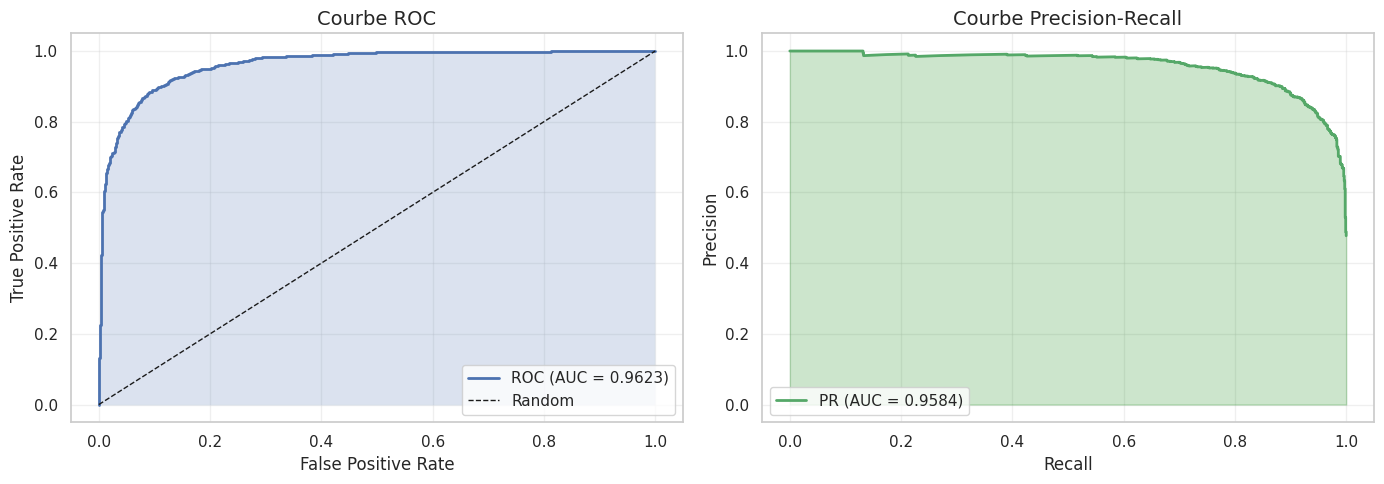

AUC-ROC: 0.9623
AUC-PR: 0.9584


In [19]:
# Courbe ROC
fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Courbe Precision-Recall
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred_proba)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, "b-", linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[0].fill_between(fpr, tpr, alpha=0.2)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Courbe ROC")
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall
axes[1].plot(recall, precision, "g-", linewidth=2, label=f"PR (AUC = {pr_auc:.4f})")
axes[1].fill_between(recall, precision, alpha=0.2, color="green")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Recall")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "gender_roc_pr_curves.png", dpi=150)
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")
print(f"AUC-PR: {pr_auc:.4f}")

## 14. Matrice de Confusion


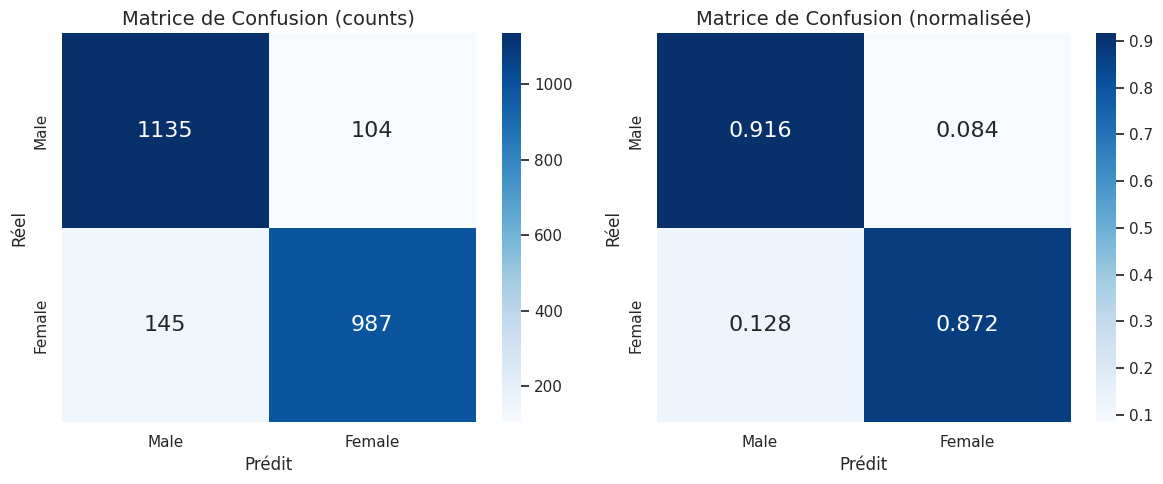


True Negatives (Male correct): 1135
False Positives (Male as Female): 104
False Negatives (Female as Male): 145
True Positives (Female correct): 987


In [20]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Counts
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
    annot_kws={"size": 16},
)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de Confusion (counts)")

# Normalized
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
    annot_kws={"size": 16},
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Matrice de Confusion (normalisée)")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "gender_confusion_matrix.png", dpi=150)
plt.show()

# Métriques dérivées
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (Male correct): {tn}")
print(f"False Positives (Male as Female): {fp}")
print(f"False Negatives (Female as Male): {fn}")
print(f"True Positives (Female correct): {tp}")

## 15. Analyse de la Confiance


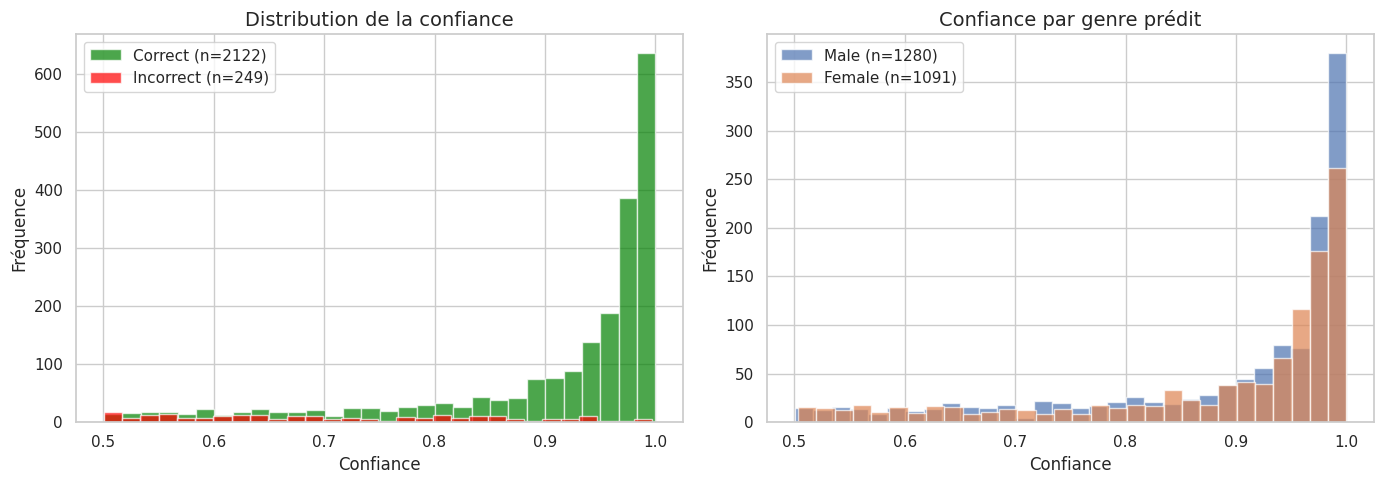

Confiance moyenne (correct): 0.907
Confiance moyenne (incorrect): 0.712


In [21]:
# Créer DataFrame des résultats
results_df = pd.DataFrame(
    {
        "true": y_true,
        "predicted": y_pred,
        "true_name": [GENDER_MAP[y] for y in y_true],
        "predicted_name": [GENDER_MAP[y] for y in y_pred],
        "correct": y_pred == y_true,
        "confidence": np.where(y_pred == 1, y_pred_proba, 1 - y_pred_proba),
    }
)

# Distribution de la confiance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par correctitude
correct_conf = results_df[results_df["correct"]]["confidence"]
incorrect_conf = results_df[~results_df["correct"]]["confidence"]

axes[0].hist(
    correct_conf,
    bins=30,
    alpha=0.7,
    label=f"Correct (n={len(correct_conf)})",
    color="green",
)
axes[0].hist(
    incorrect_conf,
    bins=30,
    alpha=0.7,
    label=f"Incorrect (n={len(incorrect_conf)})",
    color="red",
)
axes[0].set_xlabel("Confiance")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution de la confiance")
axes[0].legend()

# Par classe prédite
male_conf = results_df[results_df["predicted"] == 0]["confidence"]
female_conf = results_df[results_df["predicted"] == 1]["confidence"]

axes[1].hist(
    male_conf, bins=30, alpha=0.7, label=f"Male (n={len(male_conf)})", color="#4C72B0"
)
axes[1].hist(
    female_conf,
    bins=30,
    alpha=0.7,
    label=f"Female (n={len(female_conf)})",
    color="#DD8452",
)
axes[1].set_xlabel("Confiance")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Confiance par genre prédit")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Confiance moyenne (correct): {correct_conf.mean():.3f}")
print(f"Confiance moyenne (incorrect): {incorrect_conf.mean():.3f}")

## 16. Exemples de Prédictions


2026-01-18 12:55:14.221185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:55:14.307606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:55:14.730913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-18 12:55:14.817273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


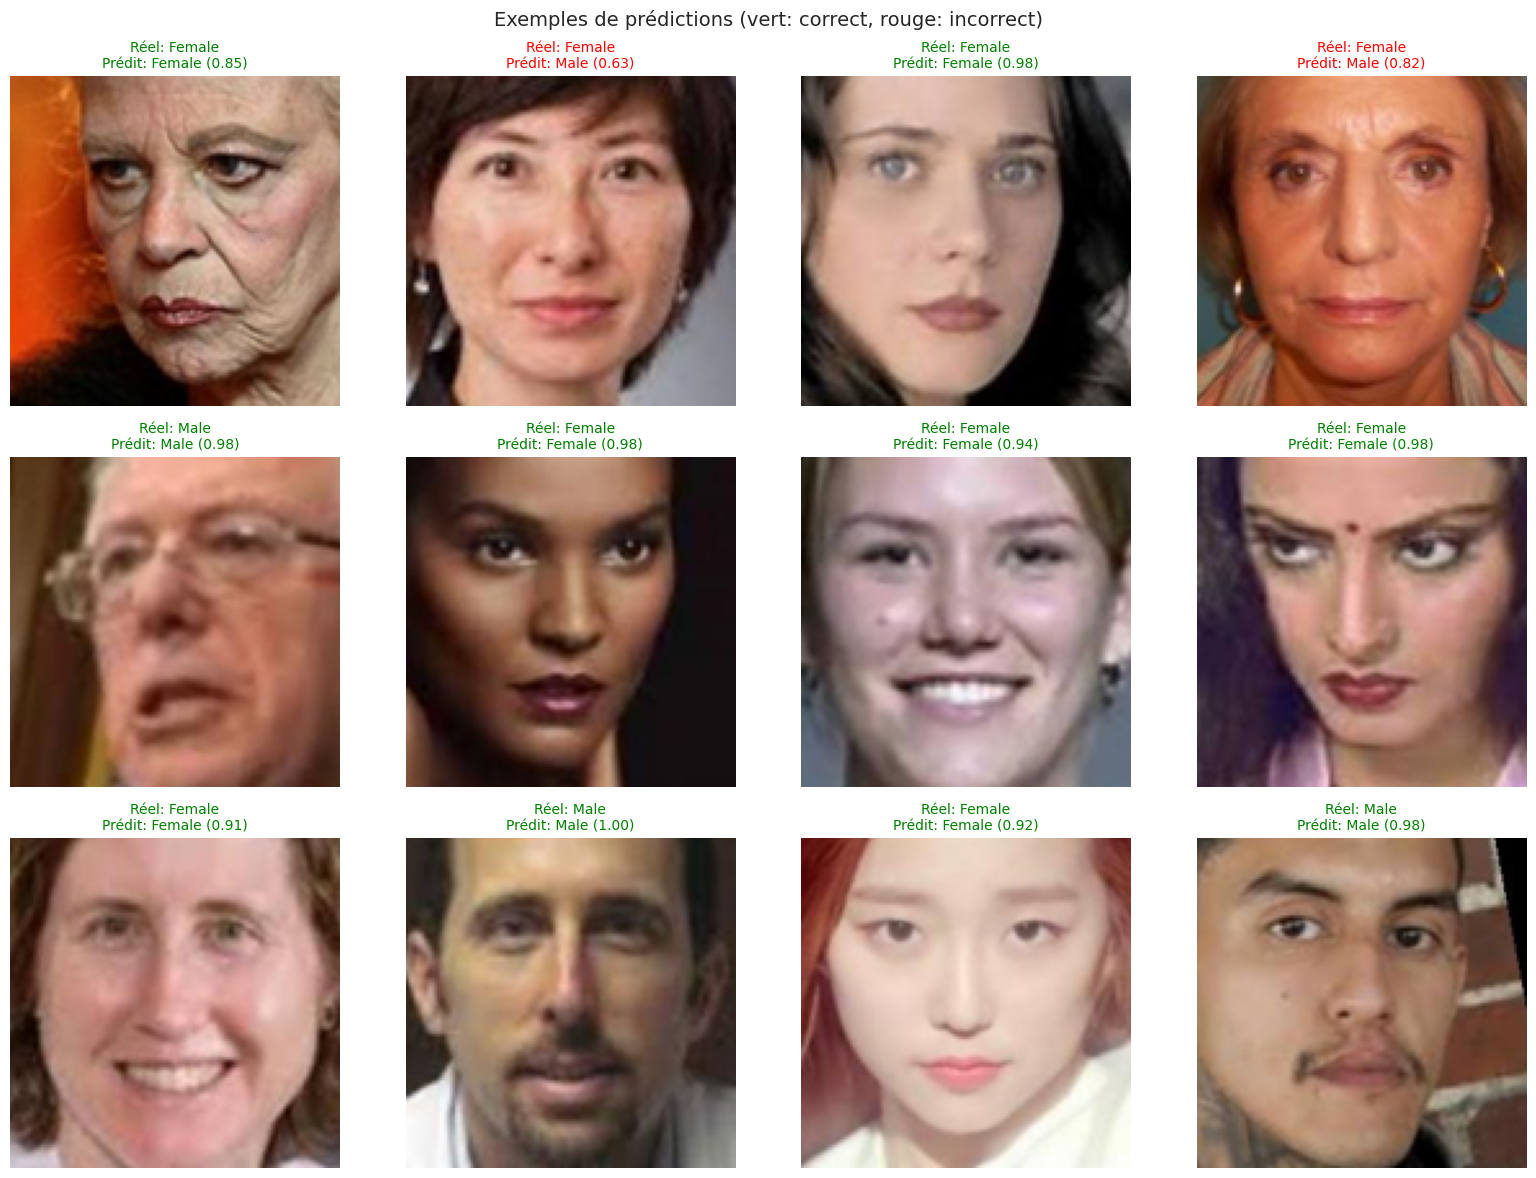

In [22]:
def show_predictions(model, filepaths, true_labels, n_samples=12):
    """Affiche une grille de prédictions."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for idx, ax in zip(indices, axes.flat):
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)  # En [0, 255]

        proba = model.predict(img_array[np.newaxis, ...], verbose=0)[0, 0]
        pred = int(proba > 0.5)
        conf = proba if pred == 1 else 1 - proba
        true = true_labels[idx]

        # Afficher l'image originale (normalisée en [0, 1])
        ax.imshow(img_array / 255.0)
        color = "green" if pred == true else "red"
        ax.set_title(
            f"Réel: {GENDER_MAP[true]}\nPrédit: {GENDER_MAP[pred]} ({conf:.2f})",
            color=color,
            fontsize=10,
        )
        ax.axis("off")

    plt.suptitle(
        "Exemples de prédictions (vert: correct, rouge: incorrect)", fontsize=14
    )
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "gender_predictions_examples.png", dpi=150)
    plt.show()


show_predictions(best_model, X_test, y_test)

## 17. Sauvegarde du Modèle Final


In [23]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "gender_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

# Sauvegarder les infos du modèle
import json

model_info = {
    "img_size": IMG_SIZE,
    "classes": CLASS_NAMES,
    "class_map": {str(k): v for k, v in GENDER_MAP.items()},
    "threshold": 0.5,
    "input_range": [0, 255],  # Plage des valeurs d'entrée attendues
}

with open(ARTIFACTS_DIR / "gender_model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print(f"Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/gender_model_final.keras
Infos du modèle sauvegardées


In [24]:
# Conversion en TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "gender_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_path.stat().st_size / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpuybucp1x/assets


INFO:tensorflow:Assets written to: /tmp/tmpuybucp1x/assets


Saved artifact at '/tmp/tmpuybucp1x'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  124000617857872: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  124000617861904: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  124005769031568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124280720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124280336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124281488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124281680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124281872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124278224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123998124281296: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1768737324.916719   38776 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768737324.916740   38776 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768737325.026334   38776 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 18. Résumé des Performances


In [25]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE DE CLASSIFICATION DE GENRE")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Classes: {CLASS_NAMES}")
print(
    f"Dataset: {len(df)} images (train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)})"
)
print(f"\nPerformances sur le test set:")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - F1 Score: {f1:.4f}")
print(f"  - AUC-ROC: {roc_auc:.4f}")
print(f"  - AUC-PR: {pr_auc:.4f}")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE DE CLASSIFICATION DE GENRE

Architecture: EfficientNetB0 + Dense Head
Input size: 128x128x3
Classes: ['Male', 'Female']
Dataset: 23708 images (train: 18966, val: 2371, test: 2371)

Performances sur le test set:
  - Accuracy: 0.8950 (89.50%)
  - F1 Score: 0.8880
  - AUC-ROC: 0.9623
  - AUC-PR: 0.9584

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/gender_model_final.keras
  - /home/optimalako/Projet/SAE/artifacts/gender_model.tflite
